# 01 — EDA

Quick look at the data, class imbalance, and the structural facts that motivate per-card sequences.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from fraud.data import load_raw_csv, feature_engineering


In [2]:
train = load_raw_csv(ROOT / 'data/raw/fraudTrain.csv')
test = load_raw_csv(ROOT / 'data/raw/fraudTest.csv')
print('train rows:', len(train), '  test rows:', len(test))
print('train fraud rate:', train['is_fraud'].mean())
print('test fraud rate :', test['is_fraud'].mean())


train rows: 471090   test rows: 555719
train fraud rate: 0.006160194782726831
test fraud rate : 0.0038598644278853163


## Class imbalance

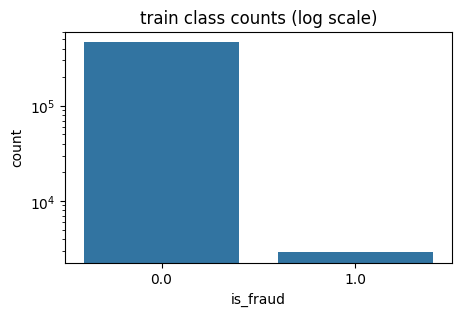

In [3]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(x='is_fraud', data=train, ax=ax)
ax.set_yscale('log')
ax.set_title('train class counts (log scale)')
plt.show()


## Per-card transaction histogram (motivates LSTM sequences)

unique cards: 938
count     938.000000
mean      502.228145
std       283.319696
min         7.000000
25%       204.000000
50%       527.500000
75%       734.750000
max      1193.000000
dtype: float64


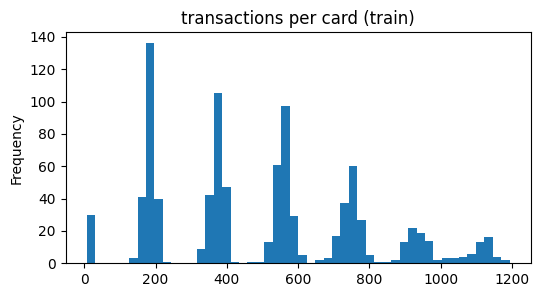

In [4]:
tx_per_card = train.groupby('cc_num').size()
print('unique cards:', tx_per_card.shape[0])
print(tx_per_card.describe())
fig, ax = plt.subplots(figsize=(6, 3))
tx_per_card.plot.hist(bins=50, ax=ax)
ax.set_title('transactions per card (train)')
plt.show()


## Card overlap between train and test

In [5]:
train_cards = set(train['cc_num'].unique())
test_cards = set(test['cc_num'].unique())
print('train cards:', len(train_cards))
print('test cards :', len(test_cards))
print('test cards also in train:', len(test_cards & train_cards))
print('cold-start test cards    :', len(test_cards - train_cards))


train cards: 938
test cards : 924
test cards also in train: 908
cold-start test cards    : 16


## Why per-card sequences matter

The cell below makes a single empirical point: **the same dollar amount can be suspicious for one card and routine for another**, and that contextual information is exactly what a row-wise classifier (RF, SVM) misses.

### Two distributions, side by side

The plot has two panels. Both show fraud vs non-fraud histograms of transaction amount.

- **Left — global distribution.** Pool every transaction in the dataset and plot `amt`. Fraud and non-fraud overlap heavily: most fraud charges are small (≈$20–$200), and so are most non-fraud charges (coffee, groceries, …). So `amt` alone, as a global feature, only weakly separates the classes.
- **Right — same amounts, z-scored per card.** Instead of comparing each transaction to *all transactions everywhere*, compare it to *that card's own spending pattern*:

  $$ \text{amt\_zscore} = \frac{\text{amt} - \text{card\_mean}}{\text{card\_std}} $$

  Now each transaction is in units of "how unusual is this for *this* card". The right panel shows non-fraud clustered tightly around zero (each card's own normal) and fraud shifted far to the right — many standard deviations above the card's baseline. Clean separation.

### Worked example: the same $200 charge on two cards

| | Card A (small spender) | Card B (big spender) |
|---|---|---|
| Card's typical mean   | $10  | $250 |
| Card's typical std    | $3   | $80  |
| **Same $200 charge** → z-score | **+63 σ** (wildly anomalous) | **−0.6 σ** (totally normal) |

The same $200 transaction is suspicious for Card A and boring for Card B. The global view can't tell them apart — they're both just "$200 charges". The z-scored view can.

### Why this motivates the LSTM

The RF baseline sees one row at a time, with no notion of "this card's normal". It cannot tell apart the two columns of the table above. The LSTM, by contrast, gets the last 20 transactions of the same card as input, so it can implicitly learn each card's baseline and flag deviations — the same signal we computed by hand here as `amt_zscore`, but learned end-to-end from the sequence and combined with the other 77 features.

So this cell is doing two jobs: showing readers a picture they can immediately understand, **and** explaining empirically why per-card context should help.


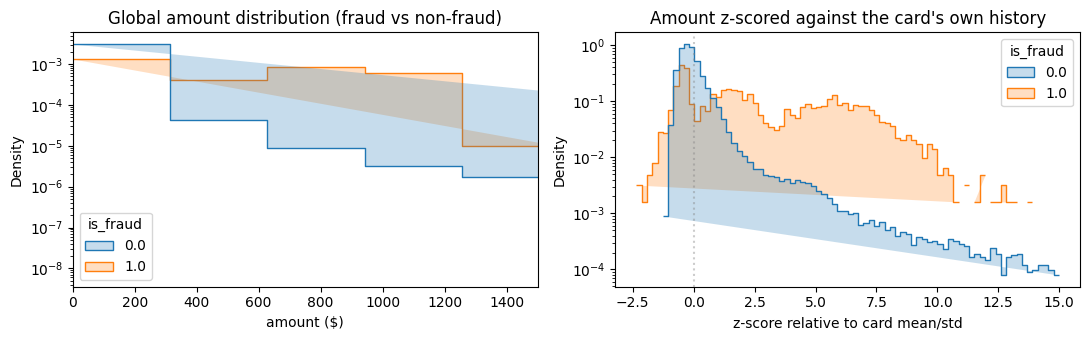

In [6]:
card_stats = train.groupby('cc_num')['amt'].agg(['mean', 'std']).rename(columns={'mean': 'card_mean', 'std': 'card_std'})
df_card = train.merge(card_stats, left_on='cc_num', right_index=True)
df_card['amt_zscore_card'] = (df_card['amt'] - df_card['card_mean']) / df_card['card_std'].replace(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(data=df_card, x='amt', hue='is_fraud', bins=80,
             log_scale=(False, True), ax=axes[0],
             common_norm=False, stat='density', element='step')
axes[0].set_xlim(0, 1500)
axes[0].set_title('Global amount distribution (fraud vs non-fraud)')
axes[0].set_xlabel('amount ($)')

clipped = df_card[df_card['amt_zscore_card'].between(-5, 15)]
sns.histplot(data=clipped, x='amt_zscore_card', hue='is_fraud', bins=80,
             log_scale=(False, True), ax=axes[1],
             common_norm=False, stat='density', element='step')
axes[1].axvline(0, color='gray', linestyle=':', alpha=0.4)
axes[1].set_title("Amount z-scored against the card's own history")
axes[1].set_xlabel('z-score relative to card mean/std')
plt.tight_layout()
plt.show()


## One card's transaction stream over time

Pick a single card with both fraud and non-fraud transactions and plot its amounts over time. The fraud points (red) tend to cluster at amounts and times that look anomalous *relative to this specific card's history* — a pattern the LSTM picks up directly via its sliding window over recent transactions on the same card.

Card …2337: 363 transactions, 19 fraud


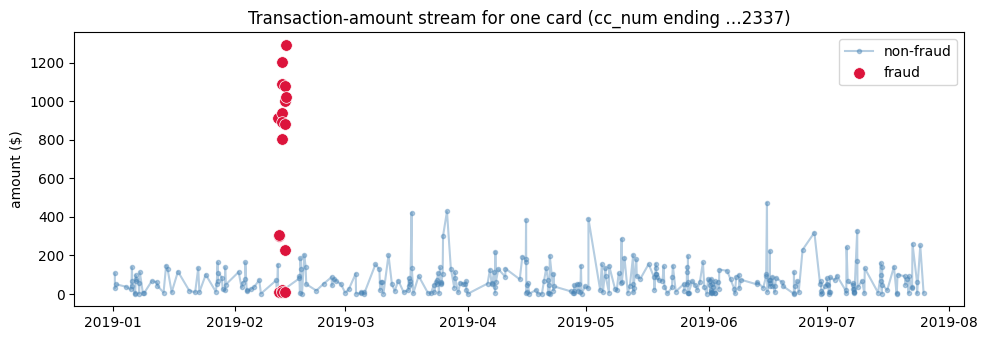

In [7]:
fraud_per_card = train[train['is_fraud'] == 1]['cc_num'].value_counts()
# Pick a card with a moderate number of fraud cases (so the plot stays readable)
candidates = fraud_per_card[fraud_per_card.between(3, 20)].index
chosen = candidates[0]
card_df = train[train['cc_num'] == chosen].sort_values('trans_date_trans_time').copy()
print(f'Card …{str(chosen)[-4:]}: {len(card_df)} transactions, {int(card_df["is_fraud"].sum())} fraud')

fig, ax = plt.subplots(figsize=(10, 3.5))
non_fraud = card_df[card_df['is_fraud'] == 0]
fraud = card_df[card_df['is_fraud'] == 1]
ax.plot(non_fraud['trans_date_trans_time'], non_fraud['amt'],
        'o-', color='steelblue', alpha=0.4, markersize=3, label='non-fraud')
ax.scatter(fraud['trans_date_trans_time'], fraud['amt'],
           s=70, color='crimson', label='fraud', zorder=3, edgecolor='white', linewidth=0.5)
ax.set_title(f'Transaction-amount stream for one card (cc_num ending …{str(chosen)[-4:]})')
ax.set_ylabel('amount ($)')
ax.legend()
plt.tight_layout()
plt.show()


## Same card, different hours of the day

Most cards have a stable pattern of when they're used. For the card above, fraud transactions concentrate in hours that don't match the card's normal usage — another piece of contextual signal the LSTM gets from the sequence (via the cyclical hour encoding combined with the per-card history).

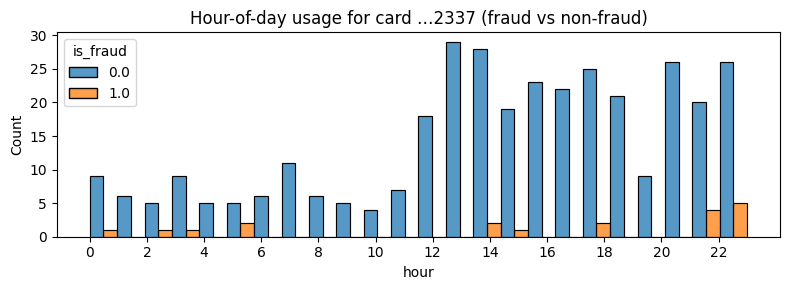

In [8]:
card_df['hour'] = card_df['trans_date_trans_time'].dt.hour
fig, ax = plt.subplots(figsize=(8, 3))
sns.histplot(data=card_df, x='hour', hue='is_fraud', bins=24,
             multiple='dodge', stat='count', ax=ax)
ax.set_title(f'Hour-of-day usage for card …{str(chosen)[-4:]} (fraud vs non-fraud)')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()
